<a href="https://colab.research.google.com/github/JaredOzarzak/biomechanics-analysis-pipeline/blob/main/Jared_Ozarzak_Lab5_HittingAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import urllib.request
import zipfile
import os

GROUP = 'lannister'
zip_dir = 'kin6016/lab5'
os.makedirs(zip_dir, exist_ok=True)

zip_filename = f'spring2026_lab5_{GROUP}.zip'
url = f'https://raw.githubusercontent.com/plnu-biomechanics/kin6016/main/labs/{zip_filename}'
zip_path = os.path.join(zip_dir, zip_filename)

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(zip_dir)

print('Extracted files in lab directory:')
print(os.listdir(zip_dir))

Extracted files in lab directory:
['Lannister_Lab5_SB_05.txt', 'Lannister_Lab5_BB_03.txt', 'Lannister_Lab5_BB_04.txt', 'Lannister_Lab5_BB_05.txt', 'Lannister_Lab5_BB_01.txt', 'Lannister_Lab5_SB_03.txt', 'Lannister_Lab5_SB_04.txt', 'Lannister_Lab5_BB_02.txt', 'Lannister_Lab5_SB_02.txt', 'spring2026_lab5_lannister.zip', 'Lannister_Lab5_SB_01.txt']


In [3]:
!pip install spm1d -q
print('spm1d library installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 18.7 MB/s eta 0:00:00
spm1d library installed.


In [4]:
import pandas as pd
import glob
import numpy as np
import spm1d
import matplotlib.pyplot as plt

print('All packages imported successfully.')

All packages imported successfully.


In [13]:
def plot_spm(ax, bb_data, sb_data, ylabel, title, show_legend=False):
    import spm1d

    # 1. Run the math
    t = spm1d.stats.ttest2(bb_data, sb_data)
    ti = t.inference(0.05, two_tailed=True, interp=True)

    # 2. Plot the Baseball and Softball lines
    spm1d.plot.plot_mean_sd(bb_data, ax=ax, linecolor='b', facecolor=(0,0,1,0.2), label='Baseball')
    spm1d.plot.plot_mean_sd(sb_data, ax=ax, linecolor='r', facecolor=(1,0,0,0.2), label='Softball')

    # 3. THE FIX: Manually draw the grey significance regions
    if hasattr(ti, 'clusters'):
        for cluster in ti.clusters:
            start, end = cluster.endpoints
            ax.axvspan(start, end, facecolor='gray', alpha=0.3)

    # 4. Clean up the labels
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('% Swing')
    if show_legend:
        ax.legend(fontsize=8)

In [14]:
file_paths = glob.glob('kin6016/lab5/*.txt')
ts_cols = ['Pelvis_Ang_Vel_mag', 'Thorax_Ang_Vel_mag', 'Back_Hip_JTP', 'Lead_Hip_JTP', 'L5S1_JTP']

discrete_list = []
ts_list = []

for file in file_paths:
    filename = os.path.basename(file)
    condition = 'BB' if 'BB' in filename else 'SB'

    df_raw = pd.read_csv(file, sep='\t', header=None, low_memory=False)
    discrete_vals = df_raw.iloc[5, 0:3].tolist()
    discrete_list.append([filename, condition] + discrete_vals)

    df_ts = pd.read_csv(file, sep='\t', header=1, low_memory=False)
    df_ts.columns = df_ts.columns.str.strip()
    valid_cols = [col for col in ts_cols if col in df_ts.columns]

    df_ts_filtered = df_ts[valid_cols].apply(pd.to_numeric, errors='coerce').dropna().head(101).copy()
    df_ts_filtered['Condition'] = condition
    df_ts_filtered['File'] = filename
    ts_list.append(df_ts_filtered)

timeseries_df = pd.concat(ts_list, ignore_index=True)
print('Data successfully parsed.')

Data successfully parsed.


In [15]:
import scipy.interpolate

spm_arrays = {}

for col in ts_cols:
    for condition in ['BB', 'SB']:
        condition_data = timeseries_df[timeseries_df['Condition'] == condition]
        swings = condition_data['File'].unique()

        matrix = []
        for swing in swings:
            swing_data = condition_data[condition_data['File'] == swing][col].values
            # Clean out the blank rows
            swing_data = swing_data[~np.isnan(swing_data)]

            # If the swing has data, stretch it smoothly to exactly 101 frames
            if len(swing_data) > 50:
                x_old = np.linspace(0, 100, len(swing_data))
                x_new = np.linspace(0, 100, 101)
                interpolator = scipy.interpolate.interp1d(x_old, swing_data, kind='linear')
                swing_101_frames = interpolator(x_new)
                matrix.append(swing_101_frames)

        spm_arrays[f'{col}_{condition}'] = np.array(matrix)

print('SUCCESS: Time-series data wrangled and standardized to exactly 101 frames!')

SUCCESS: Time-series data wrangled and standardized to exactly 101 frames!


Saved: kin6016/lab5/Fig1_SPM_Kinematics_BB_vs_SB.png


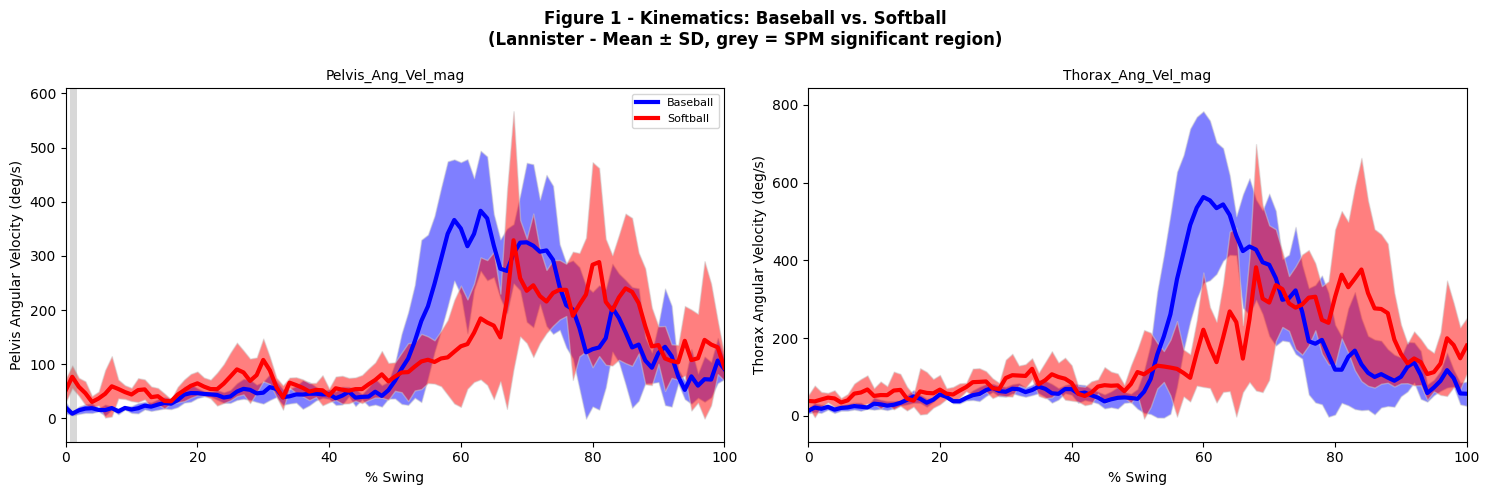

In [16]:
# Safety fallbacks just in case Colab forgot your variables
current_group = GROUP if 'GROUP' in locals() else 'lannister'
save_dir = zip_dir if 'zip_dir' in locals() else 'kin6016/lab5'

fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
fig1.suptitle(f'Figure 1 - Kinematics: Baseball vs. Softball\n({current_group.capitalize()} - Mean ± SD, grey = SPM significant region)',
             fontsize=12, fontweight='bold')

kin_panels = [
    ('Pelvis_Ang_Vel_mag', 'Pelvis Angular Velocity (deg/s)'),
    ('Thorax_Ang_Vel_mag', 'Thorax Angular Velocity (deg/s)')
]

for ax, (var, ylabel) in zip(axes1, kin_panels):
    try:
        # Check if the data exists before trying to plot
        bb_data = spm_arrays[f'{var}_BB']
        sb_data = spm_arrays[f'{var}_SB']
        plot_spm(ax, bb_data, sb_data, ylabel, var, show_legend=(var == 'Pelvis_Ang_Vel_mag'))
    except KeyError:
        ax.set_title(f"🚨 Missing Data: {var}")
        print(f"🚨 Missing data for {var}! Python couldn't find it in spm_arrays.")
    except Exception as e:
        ax.set_title(f"🚨 Math Error: {var}")
        print(f"🚨 SPM Math error on {var}: {e}")

plt.tight_layout()

try:
    fig1_path = os.path.join(save_dir, 'Fig1_SPM_Kinematics_BB_vs_SB.png')
    # THIS LINE WAS BROKEN IN YOUR CODE:
    plt.savefig(fig1_path, dpi=180, bbox_inches='tight')
    print(f"Saved: {fig1_path}")
except Exception as e:
    print("Could not save the image file to the folder, but it should still display below.")

plt.show()

Saved: kin6016/lab5/Fig2_EnergyFlow_BB_vs_SB.png


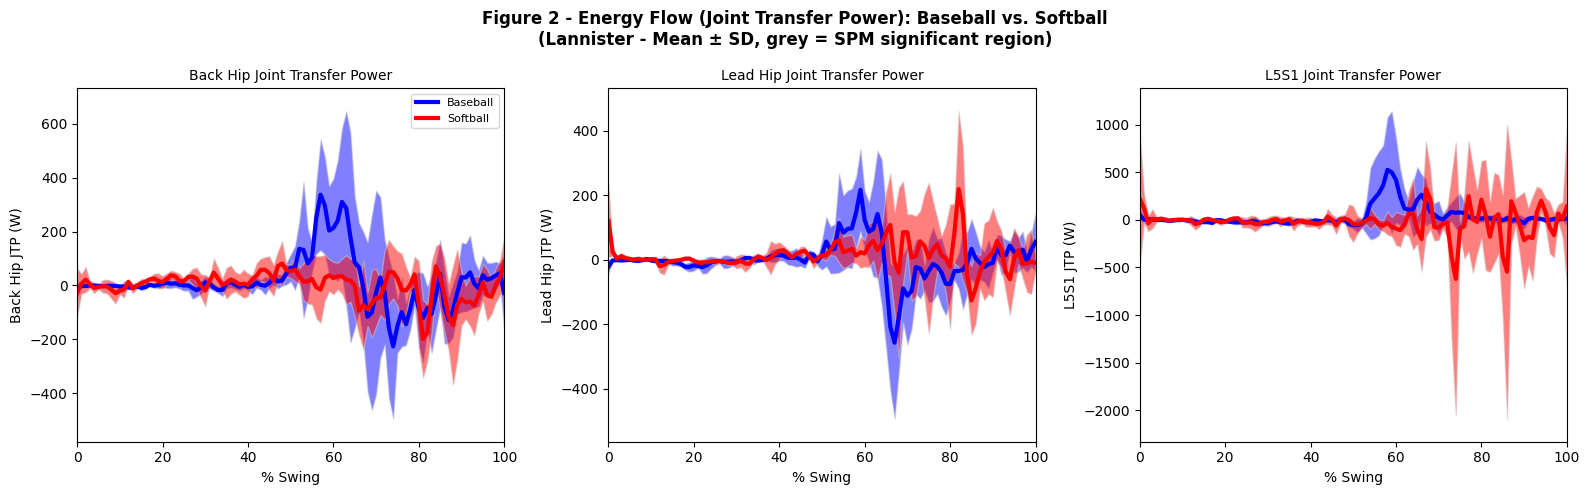

In [18]:
# Safety fallbacks just in case Colab forgot your variables
current_group = GROUP if 'GROUP' in locals() else 'lannister'
save_dir = zip_dir if 'zip_dir' in locals() else 'kin6016/lab5'

# Figure 2 - Energy Flow (Joint Transfer Power)
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle(f'Figure 2 - Energy Flow (Joint Transfer Power): Baseball vs. Softball\n({current_group.capitalize()} - Mean ± SD, grey = SPM significant region)',
             fontsize=12, fontweight='bold')

energy_panels = [
    ('Back_Hip_JTP', 'Back Hip JTP (W)', 'Back Hip Joint Transfer Power'),
    ('Lead_Hip_JTP', 'Lead Hip JTP (W)', 'Lead Hip Joint Transfer Power'),
    ('L5S1_JTP', 'L5S1 JTP (W)', 'L5S1 Joint Transfer Power')
]

for ax, (var, ylabel, title) in zip(axes2, energy_panels):
    try:
        # Check if the data exists before trying to plot
        bb_data = spm_arrays[f'{var}_BB']
        sb_data = spm_arrays[f'{var}_SB']
        plot_spm(ax, bb_data, sb_data, ylabel, title, show_legend=(var == 'Back_Hip_JTP'))
    except KeyError:
        ax.set_title(f"🚨 Missing Data: {var}")
        print(f"🚨 Missing data for {var}! Python couldn't find it in spm_arrays.")
    except Exception as e:
        ax.set_title(f"🚨 Math Error: {var}")
        print(f"🚨 SPM Math error on {var}: {e}")

plt.tight_layout()

try:
    fig2_path = os.path.join(save_dir, 'Fig2_EnergyFlow_BB_vs_SB.png')
    plt.savefig(fig2_path, dpi=180, bbox_inches='tight')
    print(f"Saved: {fig2_path}")
except Exception as e:
    print("Could not save the image file to the folder, but it should still display below.")

plt.show()

In [22]:
# Re-extracting discrete metrics to fix the shifted columns and NaN means
discrete_list_fixed = []
for file in file_paths:
    filename = os.path.basename(file)
    condition = 'BB' if 'BB' in filename else 'SB'
    df_raw = pd.read_csv(file, sep='\t', header=None, low_memory=False)

    # Grab the correct columns (1, 2, and 3) and force them to be floats (math numbers)
    discrete_vals = [float(x) for x in df_raw.iloc[5, 1:4]]
    discrete_list_fixed.append([filename, condition] + discrete_vals)

# Build the table
discrete_df = pd.DataFrame(discrete_list_fixed, columns=['File Name', 'Condition', 'Bat Speed (m/s)', 'Peak Back Leg GRF (N)', 'Back Hip Energy Transfer (J)'])
display_df = discrete_df.sort_values(by=['Condition', 'File Name']).reset_index(drop=True)

# Calculate the Means
means_df = display_df.groupby('Condition').mean(numeric_only=True).reset_index()
means_df.insert(1, 'File Name', 'MEAN')
final_df = pd.concat([display_df, means_df]).sort_values(by=['Condition', 'File Name']).reset_index(drop=True)

# Show the perfect table
display(final_df)

,File Name,Condition,Bat Speed (m/s),Peak Back Leg GRF (N),Back Hip Energy Transfer (J)
0,Lannister_Lab5_BB_01.txt,BB,31.899080,760.835510,47.268430
1,Lannister_Lab5_BB_02.txt,BB,32.396820,758.325680,41.834160
2,Lannister_Lab5_BB_03.txt,BB,32.459680,749.055050,39.075710
3,Lannister_Lab5_BB_04.txt,BB,33.369990,744.949520,41.344960
4,Lannister_Lab5_BB_05.txt,BB,33.055070,771.460330,53.091660
5,MEAN,BB,32.636128,756.925218,44.522984
6,Lannister_Lab5_SB_01.txt,SB,24.196530,595.908810,16.072240
7,Lannister_Lab5_SB_02.txt,SB,25.209430,621.103390,2.933650
8,Lannister_Lab5_SB_03.txt,SB,26.685110,628.565310,1.270020
9,Lannister_Lab5_SB_04.txt,SB,26.378740,662.619320,7.948570


In [23]:
means_df = display_df.groupby('Condition').mean(numeric_only=True).reset_index()
means_df.insert(1, 'File Name', 'MEAN')
final_df = pd.concat([display_df, means_df]).sort_values(by=['Condition', 'File Name']).reset_index(drop=True)
print("Averages calculated.")

Averages calculated.


In [24]:
display(final_df)

,File Name,Condition,Bat Speed (m/s),Peak Back Leg GRF (N),Back Hip Energy Transfer (J)
0,Lannister_Lab5_BB_01.txt,BB,31.899080,760.835510,47.268430
1,Lannister_Lab5_BB_02.txt,BB,32.396820,758.325680,41.834160
2,Lannister_Lab5_BB_03.txt,BB,32.459680,749.055050,39.075710
3,Lannister_Lab5_BB_04.txt,BB,33.369990,744.949520,41.344960
4,Lannister_Lab5_BB_05.txt,BB,33.055070,771.460330,53.091660
5,MEAN,BB,32.636128,756.925218,44.522984
6,Lannister_Lab5_SB_01.txt,SB,24.196530,595.908810,16.072240
7,Lannister_Lab5_SB_02.txt,SB,25.209430,621.103390,2.933650
8,Lannister_Lab5_SB_03.txt,SB,26.685110,628.565310,1.270020
9,Lannister_Lab5_SB_04.txt,SB,26.378740,662.619320,7.948570
